In [30]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def distp(A, B):
    n, m = A.shape[0], B.shape[0]
    dists = np.empty((n, m))
    
    for i in range(n):
        for j in range(m):
            delta = A[i] - B[j]
            dists[i, j] = np.sqrt(np.dot(delta, delta.T))
    
    return dists

def distm_basic(A, B):
    cov_matrix = np.cov(A, rowvar=False)
    cov_inv = np.linalg.inv(cov_matrix)
    n = A.shape[0]
    m = B.shape[0]
    dists = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            a = A[i]
            b = B[j]
            delta = a - b
            dist = np.sqrt(np.dot(np.dot(delta, cov_inv), delta.T))
            dists[i, j] = dist

    return dists

def grupuj(Z, klast):
    n = Z.shape[0]
    X = Z[np.random.choice(n, klast, replace=False)]
    Y = np.zeros(n, dtype=int)

    for _ in range(1000):
        odleglosci = distp(Z, X)
        new_Y = np.argmin(odleglosci, axis=1)

        if np.all(Y == new_Y):
            break

        Y = new_Y

        X = np.array([Z[Y == i].mean(axis=0) if np.any(Y == i)else X[i] for i in range(klast)])
    return X, Y


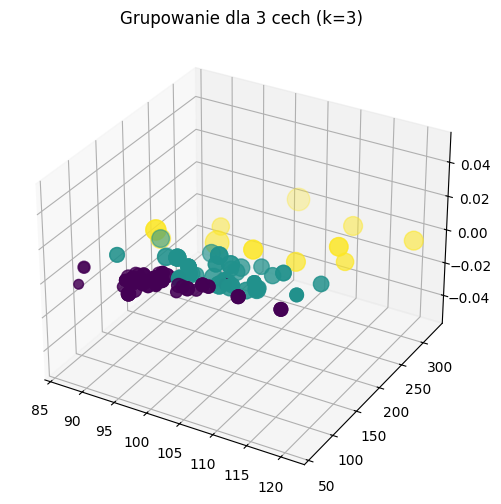

In [31]:

dane = pd.read_csv("autos.csv")

cechy_3 = ['wheel-base', 'engine-size', 'horsepower']
dane3 = dane[cechy_3].dropna().values
srd3, grp3 = grupuj(dane3, 3)

plt.figure(figsize=(8, 6))
plt.subplot(1,1,1,projection='3d')
plt.scatter(dane3[:, 0], dane3[:, 1],dane3[:,2], c=grp3)
plt.title("Grupowanie dla 3 cech (k=3)")
plt.show()


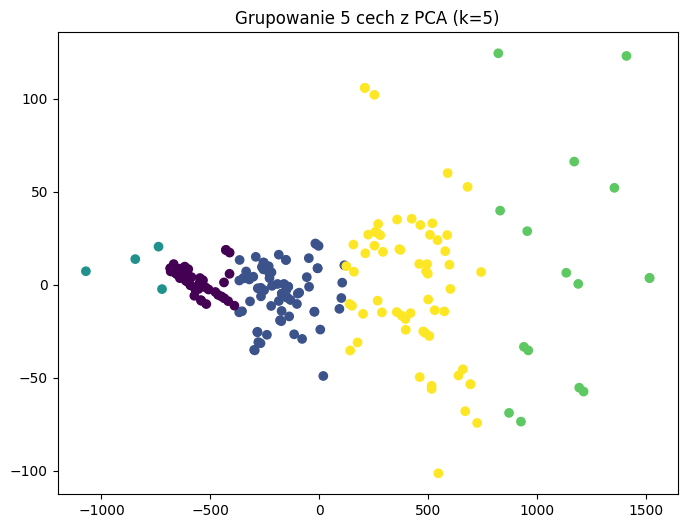

In [32]:

cechy_5 = ['wheel-base', 'curb-weight', 'engine-size', 'horsepower', 'city-mpg']
dane5 = dane[cechy_5].dropna().values
srd5, grp5 = grupuj(dane5, 5)
dane5_PCA = PCA(n_components=2).fit_transform(dane5)

plt.figure(figsize=(8, 6))
plt.scatter(dane5_PCA[:, 0], dane5_PCA[:, 1], c=grp5)
plt.title("Grupowanie 5 cech z PCA (k=5)")
plt.show()
